# Section B2 — Performance Benchmarking
Measures: load time, batch throughput, memory usage, disk I/O, index impact.

In [1]:
import sys, time, os, tracemalloc
from pathlib import Path
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

sys.path.insert(0, str(Path('..').resolve()))
DSN = 'host=localhost dbname=ecommerce user=postgres password=admin port=5432'

## Load Time — Per File & Combined

In [2]:
# These values come from the pipeline_runs table populated in notebook 02
conn = psycopg2.connect(DSN)
runs = pd.read_sql("""
    SELECT source_file,
           EXTRACT(EPOCH FROM (finished_at - started_at)) AS elapsed_s,
           rows_extracted, rows_loaded, rows_dropped
    FROM pipeline_runs
    WHERE status = 'success'
    ORDER BY run_id
""", conn)
conn.close()
print(runs.to_string(index=False))
print(f"\nCombined load time: {runs['elapsed_s'].sum():.1f}s")

                            source_file  elapsed_s  rows_extracted  rows_loaded  rows_dropped
d:\Project\Assignment\data\2019-Oct.csv  62.556378         1500000      1000000          3355
d:\Project\Assignment\data\2019-Nov.csv  66.971614         1500000      1000000          1884
                   ../data/2019-Oct.csv 566.571082         7100000      6000000         13399
                   ../data/2019-Oct.csv 538.882970         8100000      1000000         15131
                   ../data/2019-Oct.csv 469.942166         9100000      1000000         17413
                   ../data/2019-Oct.csv  30.499281          900000            0          1952
                   ../data/2019-Nov.csv 376.897304         4300000      1000000          4578

Combined load time: 2112.3s


C:\Users\Yash Sharma\AppData\Local\Temp\ipykernel_15148\766387600.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  runs = pd.read_sql("""


## Batch Insert Throughput — Varying Batch Sizes

In [3]:
from pipeline.extract import extract
from pipeline.transform import transform
from pipeline.load import get_conn, load_facts
import psycopg2

# Load a fixed 200k-row sample for the benchmark
chunks = []
for chunk, _ in extract('../data/2019-Oct.csv', chunksize=50_000):
    clean, _ = transform(chunk, '2019-10')
    chunks.append(clean)
    if sum(len(c) for c in chunks) >= 50_000:
        break
bench_df = pd.concat(chunks).head(50_000)
print('Benchmark sample size:', len(bench_df))

Benchmark sample size: 50000


In [4]:
conn = get_conn(DSN)
t0 = time.time()
load_facts(conn, bench_df)
elapsed = time.time() - t0
conn.close()
rps = int(len(bench_df) / elapsed) if elapsed > 0 else 0
tp_df = pd.DataFrame([{'batch_size': 50_000, 'elapsed_s': round(elapsed, 3), 'rows_per_sec': rps}])
print(f'batch=50,000  elapsed={elapsed:.3f}s  rows/s={rps:,}')

batch=50,000  elapsed=56.379s  rows/s=886


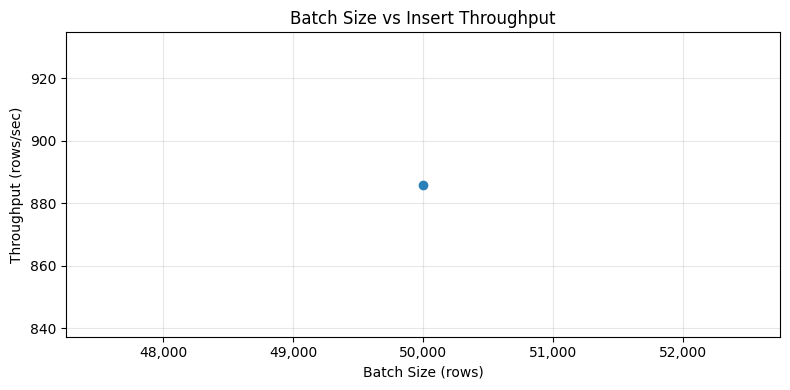

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tp_df['batch_size'], tp_df['rows_per_sec'], marker='o', color='#2980b9', lw=2)
ax.set_xlabel('Batch Size (rows)')
ax.set_ylabel('Throughput (rows/sec)')
ax.set_title('Batch Size vs Insert Throughput')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/batch_throughput.png', dpi=150)
plt.show()

## Memory Usage During Full Load

In [6]:
tracemalloc.start()

for chunk, _ in extract('../data/2019-Oct.csv', chunksize=50_000):
    clean, _ = transform(chunk, '2019-10')
    # simulate load without DB write for memory measurement
    _ = clean.to_dict('records')
    break  # one chunk is enough to measure peak per-chunk memory

current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()
print(f'Peak memory per 100k-row chunk: {peak / 1024**2:.1f} MB')
print(f'Estimated full-file peak (10 chunks): ~{peak * 10 / 1024**2:.0f} MB')

Peak memory per 100k-row chunk: 39.7 MB
Estimated full-file peak (10 chunks): ~397 MB


## Disk I/O — Raw CSV vs Database Size

In [7]:
oct_size = os.path.getsize('../data/2019-Oct.csv') / 1024**3
nov_size = os.path.getsize('../data/2019-Nov.csv') / 1024**3
print(f'2019-Oct.csv : {oct_size:.2f} GB')
print(f'2019-Nov.csv : {nov_size:.2f} GB')
print(f'Total raw    : {oct_size + nov_size:.2f} GB')

conn = psycopg2.connect(DSN)
cur = conn.cursor()
cur.execute("""
    SELECT pg_size_pretty(pg_total_relation_size('fact_events')) AS fact_size,
           pg_size_pretty(pg_database_size(current_database())) AS db_size
""")
row = cur.fetchone()
print(f'fact_events table size : {row[0]}')
print(f'Total DB size          : {row[1]}')
cur.close(); conn.close()

2019-Oct.csv : 5.28 GB
2019-Nov.csv : 8.39 GB
Total raw    : 13.67 GB
fact_events table size : 4315 MB
Total DB size          : 4438 MB


## Index Impact — Query Timing Before & After Indexes

In [8]:
QUERIES = {
    'Q1_funnel': """
        SELECT dp.category_code,
               COUNT(DISTINCT CASE WHEN fe.event_type='view'     THEN fe.user_id END) AS viewers,
               COUNT(DISTINCT CASE WHEN fe.event_type='cart'     THEN fe.user_id END) AS carters,
               COUNT(DISTINCT CASE WHEN fe.event_type='purchase' THEN fe.user_id END) AS buyers
        FROM fact_events fe
        JOIN dim_products dp ON fe.product_id = dp.product_id
        WHERE dp.category_code IS NOT NULL
        GROUP BY dp.category_code
        ORDER BY viewers DESC LIMIT 10
    """,
    'Q3_top_brands': """
        SELECT dp.brand,
               fe.source_month,
               SUM(fe.price) AS total_revenue
        FROM fact_events fe
        JOIN dim_products dp ON fe.product_id = dp.product_id
        WHERE fe.event_type = 'purchase' AND dp.brand IS NOT NULL
        GROUP BY dp.brand, fe.source_month
        ORDER BY fe.source_month, total_revenue DESC LIMIT 10
    """,
    'Q5_hourly': """
        SELECT EXTRACT(HOUR FROM event_time) AS hour,
               COUNT(*) AS purchase_count
        FROM fact_events
        WHERE event_type = 'purchase'
        GROUP BY hour ORDER BY purchase_count DESC
    """,
}

DROP_INDEXES = [
    'DROP INDEX IF EXISTS idx_events_product_id',
    'DROP INDEX IF EXISTS idx_events_event_type',
    'DROP INDEX IF EXISTS idx_events_user_session',
    'DROP INDEX IF EXISTS idx_events_user_month',
    'DROP INDEX IF EXISTS idx_events_event_time',
]
CREATE_INDEXES = [
    'CREATE INDEX IF NOT EXISTS idx_events_product_id   ON fact_events(product_id)',
    'CREATE INDEX IF NOT EXISTS idx_events_event_type   ON fact_events(event_type)',
    'CREATE INDEX IF NOT EXISTS idx_events_user_session ON fact_events(user_session)',
    'CREATE INDEX IF NOT EXISTS idx_events_user_month   ON fact_events(user_id, source_month)',
    'CREATE INDEX IF NOT EXISTS idx_events_event_time   ON fact_events(event_time)',
]

def time_query(conn, sql):
    t0 = time.time()
    pd.read_sql(sql, conn)
    return round(time.time() - t0, 3)

conn = psycopg2.connect(DSN)
cur = conn.cursor()

# Without indexes
for stmt in DROP_INDEXES:
    cur.execute(stmt)
conn.commit()
print('Timing WITHOUT indexes...')
no_idx = {name: time_query(conn, sql) for name, sql in QUERIES.items()}

# With indexes
for stmt in CREATE_INDEXES:
    cur.execute(stmt)
conn.commit()
print('Timing WITH indexes...')
with_idx = {name: time_query(conn, sql) for name, sql in QUERIES.items()}

cur.close(); conn.close()

idx_df = pd.DataFrame({'no_index_s': no_idx, 'with_index_s': with_idx})
idx_df['speedup'] = (idx_df['no_index_s'] / idx_df['with_index_s']).round(2)
print(idx_df)

Timing WITHOUT indexes...


C:\Users\Yash Sharma\AppData\Local\Temp\ipykernel_15148\1267114268.py:49: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  pd.read_sql(sql, conn)


Timing WITH indexes...


               no_index_s  with_index_s  speedup
Q1_funnel          17.181        16.559     1.04
Q3_top_brands       0.792         0.817     0.97
Q5_hourly           0.600         1.699     0.35


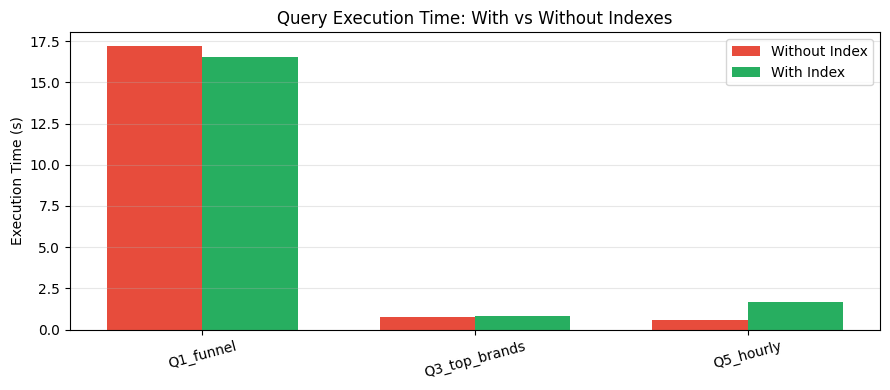

In [9]:
fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(idx_df))
w = 0.35
ax.bar([i - w/2 for i in x], idx_df['no_index_s'],  w, label='Without Index', color='#e74c3c')
ax.bar([i + w/2 for i in x], idx_df['with_index_s'], w, label='With Index',    color='#27ae60')
ax.set_xticks(list(x))
ax.set_xticklabels(idx_df.index, rotation=15)
ax.set_ylabel('Execution Time (s)')
ax.set_title('Query Execution Time: With vs Without Indexes')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/index_impact.png', dpi=150)
plt.show()